In [1]:
import os
import oracledb
from dotenv import load_dotenv
import pandas as pd

load_dotenv()

def create_cursor():
    connection = oracledb.connect(
        user=os.getenv("ORACLE_USER"),
        password=os.getenv("ORACLE_PASSWORD"),
        dsn=oracledb.makedsn("localhost", 1522, service_name="stu"),
    )
    cursor = connection.cursor()
    print("Connected to Oracle")
    return connection, cursor

# RQ1: How does average viewership and engagement of conservative and liberal YouTube channels change over time?

In [ ]:
connection, cursor = create_cursor()

rq1_query = """
SELECT
lean,
year,
ROUND(AVG(view_count), 2) AS avg_views,
ROUND(AVG(like_count), 2) AS avg_likes,
ROUND(AVG(comment_count), 2) AS avg_comments,
ROUND(AVG(like_count) / AVG(view_count) * 100, 2) AS like_rate_percent,
ROUND(AVG(comment_count) / AVG(view_count) * 100, 2) AS comment_rate_percent
FROM youtube_videos
GROUP BY lean, year
ORDER BY year, lean
"""
cursor.execute(rq1_query)
results = cursor.fetchall()
rq1_df = pd.DataFrame(results, columns=[d[0] for d in cursor.description])
display(rq1_df)

cursor.close()
connection.close()

Connected to Oracle


,LEAN,YEAR,AVG_VIEWS,AVG_LIKES,AVG_COMMENTS,LIKE_RATE_PERCENT,COMMENT_RATE_PERCENT
0,conservative,2018,98931.87,2807.23,472.17,2.84,0.48
1,liberal,2018,664.98,3.58,1.30,0.54,0.20
2,conservative,2019,147282.83,4106.68,806.75,2.79,0.55
3,liberal,2019,67.55,0.58,0.30,0.86,0.44
4,conservative,2020,2089483.87,77850.17,10907.93,3.73,0.52
5,liberal,2020,31.52,0.22,0.07,0.69,0.21
6,conservative,2021,4121860.32,168471.42,16030.22,4.09,0.39
7,liberal,2021,85.13,0.95,0.50,1.12,0.59
8,conservative,2022,3866259.97,165252.77,10849.80,4.27,0.28
9,liberal,2022,304115.98,6692.88,3497.28,2.20,1.15


LEAN,conservative,liberal
YEAR,,
2018,98931.87,664.98
2019,147282.83,67.55
2020,2089483.87,31.52
2021,4121860.32,85.13
2022,3866259.97,304115.98
2023,10121797.97,1506847.42
2024,4653955.03,877708.45
2025,1293953.02,767539.15


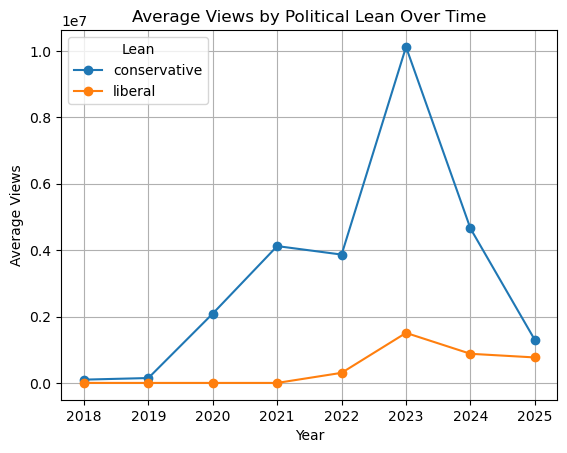

In [ ]:
import matplotlib.pyplot as plt

pivot = rq1_df.pivot(index="YEAR", columns="LEAN", values="AVG_VIEWS")
display(pivot)
pivot.plot(marker="o")
plt.title("Average Views by Political Lean Over Time")
plt.xlabel("Year")
plt.ylabel("Average Views")
plt.legend(title="Lean")
plt.grid(True)
plt.show()

# RQ2: Is YouTube political engagement related to election outcomes?

In [34]:
connection, cursor = create_cursor()
try: 
    rq2_query = """
    SELECT
    v.year,
    ROUND(AVG(v.view_count)) AS avg_views,
    ROUND(AVG(v.like_count)) AS avg_likes,
    m.candidate,
    m.party,
    SUM(m.votes) AS votes,
    SUM(m.totalvotes) AS totalvotes,
    SUM(m.votes) / SUM(m.totalvotes) * 100 AS vote_percent
    FROM youtube_videos v
    JOIN mit m ON v.year = m.year AND 
    ((v.lean = 'conservative' AND m.party = 'REPUBLICAN') OR
     (v.lean = 'liberal' AND m.party = 'DEMOCRAT')
    )
    WHERE m.party IN ('DEMOCRAT', 'REPUBLICAN')
    GROUP BY v.year, v.lean, m.candidate, m.party
    ORDER BY v.year, v.lean
    """

    cursor.execute(rq2_query)
    results = cursor.fetchall()
    rq2_df = pd.DataFrame(results, columns=[d[0] for d in cursor.description])
    display(rq2_df)
except Exception as e:
    print("Error executing query", e)

cursor.close()
connection.close()

Connected to Oracle


,YEAR,AVG_VIEWS,AVG_LIKES,CANDIDATE,PARTY,VOTES,TOTALVOTES,VOTE_PERCENT
0,2020,2089484,77850,"TRUMP, DONALD J.",REPUBLICAN,4452968760,9511710180,46.815648
1,2020,32,0,"BIDEN, JOSEPH R. JR",DEMOCRAT,4876134480,9511710180,51.264540
2,2024,4653955,223736,"TRUMP, DONALD J.",REPUBLICAN,4638154800,9324612240,49.740994
3,2024,877708,21329,"HARRIS, KAMALA D.",DEMOCRAT,4501056780,9324612240,48.270713


# RQ3: Does YouTube comment sentiment reflect voter preferences or amplify extreme views?

In [35]:
connection, cursor = create_cursor()

rq3_query = """
SELECT
v.lean,
v.year,
COUNT(c.comment_id) AS total_comments,
ROUND(AVG(c.like_count), 2) AS avg_comment_likes,
ROUND(AVG(a.democrat_thermometer), 2) AS avg_dem_thermometer,
ROUND(AVG(a.republican_thermometer), 2) AS avg_rep_thermometer,
COUNT(CASE WHEN a.youtube_use = 'Yes' THEN 1 END) AS youtube_users,
COUNT(CASE WHEN a.youtube_use = 'No'  THEN 1 END) AS non_youtube_users
FROM youtube_videos v
JOIN youtube_comments c ON v.video_id = c.video_id
JOIN anes_2020 a ON v.year = a.election_year
WHERE v.year = 2020
GROUP BY v.lean, v.year

UNION ALL

SELECT
v.lean,
v.year,
COUNT(c.comment_id),
ROUND(AVG(c.like_count), 2),
ROUND(AVG(a.democrat_thermometer), 2),
ROUND(AVG(a.republican_thermometer), 2),
COUNT(CASE WHEN a.youtube_use = 'Yes' THEN 1 END),
COUNT(CASE WHEN a.youtube_use = 'No' THEN 1 END)
FROM youtube_videos v
JOIN youtube_comments c ON v.video_id = c.video_id
JOIN anes_2024 a ON v.year = a.election_year
WHERE v.year = 2024
GROUP BY v.lean, v.year

ORDER BY year, lean
"""

cursor.execute(rq3_query)
results = cursor.fetchall()
rq3_df = pd.DataFrame(results, columns=[d[0] for d in cursor.description])
display(rq3_df)

cursor.close()
connection.close()

Connected to Oracle


,LEAN,YEAR,TOTAL_COMMENTS,AVG_COMMENT_LIKES,AVG_DEM_THERMOMETER,AVG_REP_THERMOMETER,YOUTUBE_USERS,NON_YOUTUBE_USERS
0,conservative,2020,54000,10394.29,56.39,35.44,38016,9288
1,conservative,2024,54000,8402.74,46.88,41.66,30348,18468
2,liberal,2024,54000,615.67,46.88,41.66,30348,18468
